# Fully Connected Neural Network — Bank Customer Churn Classification

This notebook predicts whether a bank customer will exit. It includes leakage-safe preprocessing, class-imbalance handling, a binary Keras network, and a complete test-set evaluation.

## 1. Import Libraries and Reproducibility

In [1]:
import os
import random
import warnings

os.environ.setdefault("KERAS_HOME", os.path.abspath(".keras"))
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".mplconfig"))

import numpy as np
import tensorflow as tf

SEED = 42
FAST_RUN = os.getenv("ASSIGNMENT_FAST_RUN", "0") == "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fast validation mode:", FAST_RUN)

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

sns.set_theme(style="whitegrid")

TensorFlow version: 2.20.0
Available GPU devices: []
Fast validation mode: False


## 2. Load Dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/mahmoudramadan155/ML/main/labs/dl/Churn_Modelling.csv"
candidate_paths = [Path("Churn_Modelling.csv"), Path("labs/dl/Churn_Modelling.csv"), Path("../dl/Churn_Modelling.csv")]
data_path = next((path for path in candidate_paths if path.exists()), None)
df = pd.read_csv(data_path if data_path else DATA_URL)
print("Loaded from:", data_path if data_path else DATA_URL)
display(df.head())

Loaded from: labs\dl\Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Exploration and Quality Checks

In [3]:
print("Dataset shape:", df.shape)
display(df.dtypes.rename("dtype").to_frame())
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

Dataset shape: (10000, 14)


,dtype
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Missing values:


,missing
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


## 4. Cleaning and Class Distribution

,count,percent
Exited,,
0,7963,79.63
1,2037,20.37


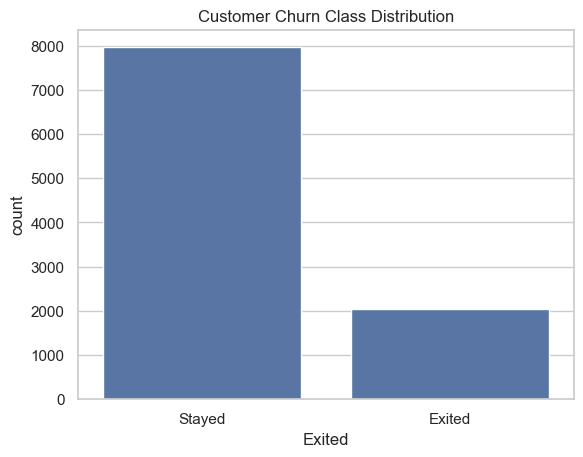

In [4]:
clean_df = df.drop_duplicates().copy()
clean_df = clean_df.drop(columns=["RowNumber", "CustomerId", "Surname"])

class_counts = clean_df["Exited"].value_counts().sort_index()
class_percent = clean_df["Exited"].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)}))

sns.countplot(data=clean_df, x="Exited")
plt.title("Customer Churn Class Distribution")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.show()

## 5. Train / Validation / Test Split

Stratification keeps the churn ratio similar in every split. The test set is held back until final evaluation.

In [5]:
X = clean_df.drop(columns="Exited")
y = clean_df["Exited"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4))

Train: (7000, 10) Validation: (1500, 10) Test: (1500, 10)
Train churn rate: 0.2037


## 6. Categorical Encoding and Feature Scaling

In [6]:
categorical_features = ["Geography", "Gender"]
numeric_features = [column for column in X.columns if column not in categorical_features]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])
X_train_ready = preprocessor.fit_transform(X_train).astype("float32")
X_val_ready = preprocessor.transform(X_val).astype("float32")
X_test_ready = preprocessor.transform(X_test).astype("float32")
print("Processed feature shape:", X_train_ready.shape)

Processed feature shape: (7000, 13)


## 7. Handle Class Imbalance

Exited customers are the minority class. Balanced class weights make errors on each class contribute more equally without changing the validation or test distributions.

In [7]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

Class weights: {np.int64(0): np.float64(0.6279153211338356), np.int64(1): np.float64(2.4544179523141656)}


## 8. Build and Compile the FCNN

Three ReLU hidden layers learn nonlinear customer patterns. A single sigmoid output gives churn probability, so binary cross-entropy is the correct loss.

In [8]:
tf.keras.backend.clear_session()
classification_model = Sequential([
    Input(shape=(X_train_ready.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
], name="churn_fcnn")

classification_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
classification_model.summary()

Model: "churn_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train Model

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]
history = classification_model.fit(
    X_train_ready,
    y_train,
    validation_data=(X_val_ready, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/50


110/110 - 2s - 21ms/step - accuracy: 0.6720 - auc: 0.6838 - loss: 0.6464 - precision: 0.3279 - recall: 0.5813 - val_accuracy: 0.6993 - val_auc: 0.7937 - val_loss: 0.5730 - val_precision: 0.3794 - val_recall: 0.7451 - learning_rate: 1.0000e-03


Epoch 2/50


110/110 - 0s - 3ms/step - accuracy: 0.6996 - auc: 0.7831 - loss: 0.5631 - precision: 0.3770 - recall: 0.7279 - val_accuracy: 0.7213 - val_auc: 0.8294 - val_loss: 0.5424 - val_precision: 0.4060 - val_recall: 0.7908 - learning_rate: 1.0000e-03


Epoch 3/50


...

110/110 - 0s - 3ms/step - accuracy: 0.8046 - auc: 0.8790 - loss: 0.4344 - precision: 0.5135 - recall: 0.7763 - val_accuracy: 0.8040 - val_auc: 0.8729 - val_loss: 0.4284 - val_precision: 0.5131 - val_recall: 0.7680 - learning_rate: 2.5000e-04


Epoch 28/50


110/110 - 0s - 3ms/step - accuracy: 0.8019 - auc: 0.8778 - loss: 0.4369 - precision: 0.5089 - recall: 0.7833 - val_accuracy: 0.8000 - val_auc: 0.8724 - val_loss: 0.4317 - val_precision: 0.5065 - val_recall: 0.7647 - learning_rate: 2.5000e-04


Epoch 29/50


110/110 - 0s - 3ms/step - accuracy: 0.7989 - auc: 0.8765 - loss: 0.4379 - precision: 0.5041 - recall: 0.7700 - val_accuracy: 0.8020 - val_auc: 0.8724 - val_loss: 0.4276 - val_precision: 0.5097 - val_recall: 0.7712 - learning_rate: 2.5000e-04


## 10. Training and Validation Graphs

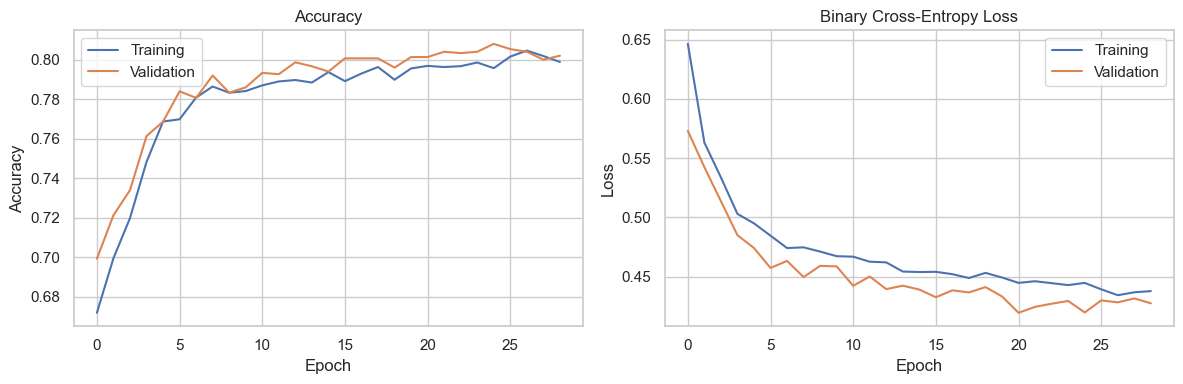

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set(title="Binary Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Test Evaluation

In [11]:
y_probability = classification_model.predict(X_test_ready, verbose=0).ravel()
y_pred = (y_probability >= 0.5).astype(int)

classification_results = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probability),
})
display(classification_results.to_frame("Test value"))
print(classification_report(y_test, y_pred, target_names=["Stayed", "Exited"]))

,Test value
Accuracy,0.802667
Precision,0.510393
Recall,0.724590
F1-score,0.598916
ROC-AUC,0.860794


              precision    recall  f1-score   support

      Stayed       0.92      0.82      0.87      1195
      Exited       0.51      0.72      0.60       305

    accuracy                           0.80      1500
   macro avg       0.72      0.77      0.73      1500
weighted avg       0.84      0.80      0.81      1500



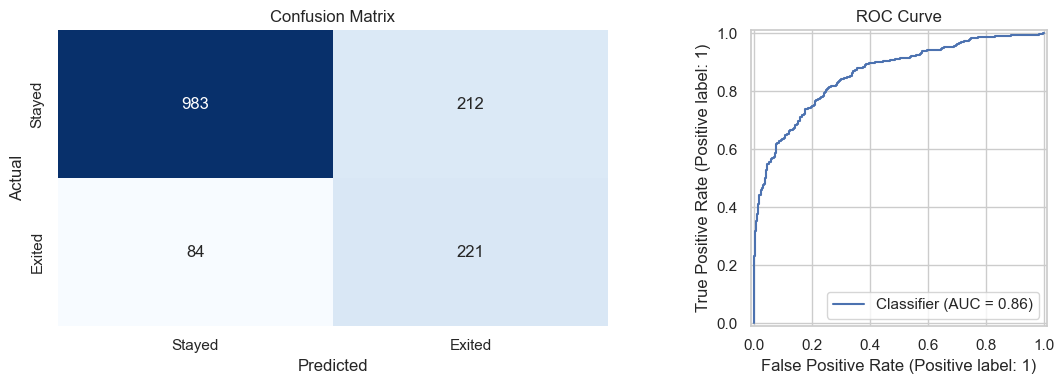

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Stayed", "Exited"], yticklabels=["Stayed", "Exited"], ax=axes[0])
axes[0].set(title="Confusion Matrix", xlabel="Predicted", ylabel="Actual")
RocCurveDisplay.from_predictions(y_test, y_probability, ax=axes[1])
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

## 12. Example Predictions

In [13]:
examples = X_test.head(10).copy()
examples["Actual"] = y_test.head(10).map({0: "Stayed", 1: "Exited"}).to_numpy()
examples["Predicted probability"] = np.round(y_probability[:10], 3)
examples["Predicted"] = np.where(y_pred[:10] == 1, "Exited", "Stayed")
display(examples[["Geography", "Gender", "Age", "Balance", "Actual", "Predicted probability", "Predicted"]])

,Geography,Gender,Age,Balance,Actual,Predicted probability,Predicted
9161,France,Male,40,163823.37,Stayed,0.257,Stayed
8692,France,Female,32,0.00,Stayed,0.082,Stayed
4616,France,Male,37,141803.77,Stayed,0.054,Stayed
5818,Germany,Female,34,102143.93,Stayed,0.144,Stayed
9093,France,Male,31,0.00,Stayed,0.373,Stayed
6345,France,Female,35,0.00,Stayed,0.089,Stayed
5587,France,Female,37,0.00,Stayed,0.088,Stayed
1606,Germany,Female,40,97001.36,Stayed,0.447,Stayed
8379,Spain,Male,55,0.00,Exited,0.900,Exited
1305,Germany,Male,52,76915.40,Exited,0.966,Exited


## 13. Conclusion

The FCNN produces a churn probability for each customer and class weighting helps it pay attention to the less frequent exited class. The untouched test-set accuracy, precision, recall, F1, ROC-AUC, confusion matrix, and classification report above provide a balanced view of final performance.